In [34]:
from langchain_core.messages import BaseMessage
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated, List
from dotenv import load_dotenv
import os

from langgraph.checkpoint.memory import MemorySaver
load_dotenv()

True

In [24]:
BASE_URL= os.getenv("BASE_URL")
llm = ChatOllama(
    model="qwen3:1.7b",
    base_url = BASE_URL
)


In [25]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [31]:
def chat_bot(state: ChatState):
    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages': response}

In [36]:
checkpoint = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_bot',chat_bot)

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)

chatbot = graph.compile(checkpointer=checkpoint)

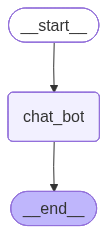

In [37]:
chatbot

In [40]:
from langchain.messages import HumanMessage

thread_id = "1"

while True:
    user_input = input("You: ")
    print("User:", user_input)
    if user_input.lower() in ["exit", "quit","out","close","stop","end","goodbye","bye"]:
        print("Exiting chat.")
        break
    initial_state = {
        "messages": [HumanMessage(content=user_input)]
    }

    config = {"configurable": {"thread_id": thread_id}}
    result = chatbot.invoke(initial_state, config=config)

    print("ChatBot:", result["messages"][-1].content)

User: my name is siddhesh
ChatBot: Your name, **Siddhesh**, is a beautiful and meaningful Indian name. Let me break it down:

### **Meaning**  
- **Siddhi** (from Sanskrit): "Achievement," "Success," or "Desire." It often symbolizes striving for excellence or a goal.  
- **Esh** (common suffix in Indian names): "Child" or "Son."  

So, **Siddhesh** can be interpreted as **"Achievement Child"** or **"Success Son"**, reflecting a desire for success and achievement in life.  

### **Cultural Significance**  
- The name is widely used in Indian cultures, particularly in regions like Bengal, Assam, and Tamil Nadu.  
- It combines the Sanskrit root **"siddhi"** (meaning "success") with the suffix **"esh"** (meaning "child/son"), making it a classic, meaningful name.  

### **Pronunciation**  
- **Siddhesh** is pronounced as **/ˈsɪdˈdəʃəs/** in English.  

### **Variations**  
- It can be combined with other names (e.g., **Siddheshwar** for a more formal or religious variation).  

### **Mode